In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = {
    'Hours': [1, 2, 3, 4, None, 6, 7],
    'Marks': [35, 50, 55, 65, 70, None, 90],
    'Gender': ['M', 'F', 'F', 'M', 'M', 'F', 'F']
}

- Questions
1. Handle missing values
2. Encode categorical column
3. Apply Linear Regression
4. Predict marks 

In [3]:
df = pd.DataFrame(data)
df

,Hours,Marks,Gender
0,1.0,35.0,M
1,2.0,50.0,F
2,3.0,55.0,F
3,4.0,65.0,M
4,NaN,70.0,M
5,6.0,NaN,F
6,7.0,90.0,F


In [4]:
df.isna().sum()

Hours     1
Marks     1
Gender    0
dtype: int64

In [5]:
df['Hours'] = df['Hours'].fillna(df['Hours'].mean())
df['Marks'] = df['Marks'].fillna(df['Marks'].mean())

In [6]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])

In [7]:
df

,Hours,Marks,Gender
0,1.000000,35.000000,1
1,2.000000,50.000000,0
2,3.000000,55.000000,0
3,4.000000,65.000000,1
4,3.833333,70.000000,1
5,6.000000,60.833333,0
6,7.000000,90.000000,0


In [8]:
X = df[['Hours', 'Gender']]
y = df['Marks']

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [10]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
pred = linear_model.predict([[5, 1]])
print(pred)

[75.21333333]


====================================================================================

In [12]:
data = {
    'Age': [22, 25, 47, 52, None, 46, 56],
    'Income': [15000, 29000, 48000, 60000, 52000, None, 75000],
    'Buy': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes']
}

In [13]:
df = pd.DataFrame(data)
df

,Age,Income,Buy
0,22.0,15000.0,No
1,25.0,29000.0,No
2,47.0,48000.0,Yes
3,52.0,60000.0,Yes
4,NaN,52000.0,Yes
5,46.0,NaN,No
6,56.0,75000.0,Yes


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     6 non-null      float64
 1   Income  6 non-null      float64
 2   Buy     7 non-null      str    
dtypes: float64(2), str(1)
memory usage: 300.0 bytes


In [15]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Income'] = df['Income'].fillna(df['Income'].mean())

In [16]:
encoder = LabelEncoder()
df['Buy'] = encoder.fit_transform(df['Buy'])

In [17]:
df

,Age,Income,Buy
0,22.000000,15000.0,0
1,25.000000,29000.0,0
2,47.000000,48000.0,1
3,52.000000,60000.0,1
4,41.333333,52000.0,1
5,46.000000,46500.0,0
6,56.000000,75000.0,1


In [18]:
X = df[['Age', 'Income']]
y = df['Buy']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5, 2) (2, 2) (5,) (2,)


In [20]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors= 3)
knn.fit(X,y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
pred = knn.predict([[45, 10000]])
if(pred == 1):
    print("BUY")
else:
    print("NO")

NO


In [22]:
data = {
    'Salary': [20000, 22000, 25000, 80000, 82000, 85000],
    'Spending': [30, 40, 35, 80, 85, 90]
}

In [23]:
df = pd.DataFrame(data)
df

,Salary,Spending
0,20000,30
1,22000,40
2,25000,35
3,80000,80
4,82000,85
5,85000,90


In [24]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters= 3)
kmeans.fit(df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [25]:
labels = kmeans.predict(df)

In [26]:
print(labels)

[1 1 1 0 0 2]


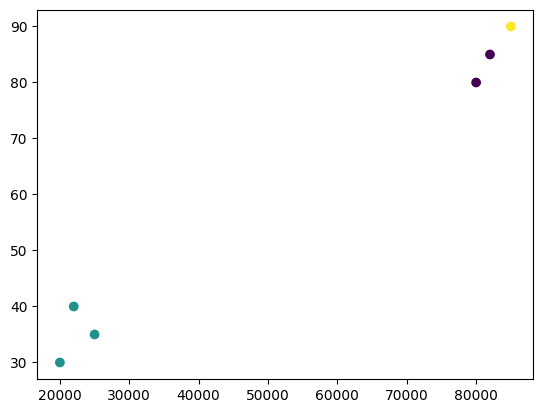

In [27]:
plt.scatter(df['Salary'], df['Spending'], c = labels)

In [28]:
df = pd.read_csv('./Datasets/marketing_campaign.csv', sep='\t')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [30]:
df.drop_duplicates(inplace= True)

In [31]:
df.drop('ID', axis= 1, inplace= True)

In [32]:
df

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,...,5,0,0,0,0,0,0,3,11,0
2236,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,...,7,0,0,0,1,0,0,3,11,0
2237,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,...,6,0,1,0,0,0,0,3,11,0
2238,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,...,3,0,0,0,0,0,0,3,11,0


In [33]:
df[['Education', 'Marital_Status', 'Dt_Customer']]

,Education,Marital_Status,Dt_Customer
0,Graduation,Single,04-09-2012
1,Graduation,Single,08-03-2014
2,Graduation,Together,21-08-2013
3,Graduation,Together,10-02-2014
4,PhD,Married,19-01-2014
...,...,...,...
2235,Graduation,Married,13-06-2013
2236,PhD,Together,10-06-2014
2237,Graduation,Divorced,25-01-2014
2238,Master,Together,24-01-2014


In [34]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Education'] = encoder.fit_transform(df['Education'])

In [35]:
df['Marital_Status'] = encoder.fit_transform(df['Marital_Status'])

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   int64  
 2   Marital_Status       2240 non-null   int64  
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   str    
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16 

In [37]:
df['Income'] = df['Income'].fillna(df['Income'].mean())

In [38]:
df['Total_Spending']  = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [39]:
df.drop(['MntWines','MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'], inplace= True, axis= 1)

In [40]:
df['Total_Child'] = df['Kidhome'] + df['Teenhome']

In [41]:
df.drop(['Kidhome', 'Teenhome'], axis= 1, inplace= True)

In [42]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format= '%d-%m-%Y')
df['Day'] = df['Dt_Customer'].dt.day
df['Month'] = df['Dt_Customer'].dt.month
df['Year'] = df['Dt_Customer'].dt.year
df.drop('Dt_Customer', axis = 1, inplace= True)

In [43]:
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Recency',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Total_Spending',
       'Total_Child', 'Day', 'Month', 'Year'],
      dtype='str')

In [44]:
X = df[['Income', 'Total_Child', 'Total_Spending', 'Recency']]
y = df['Response']

In [45]:
X

,Income,Total_Child,Total_Spending,Recency
0,58138.0,0,1617,58
1,46344.0,2,27,38
2,71613.0,0,776,26
3,26646.0,1,53,26
4,58293.0,1,422,94
...,...,...,...,...
2235,61223.0,1,1341,46
2236,64014.0,3,444,56
2237,56981.0,0,1241,91
2238,69245.0,1,843,8


In [46]:
y

0       1
1       0
2       0
3       0
4       0
       ..
2235    0
2236    0
2237    0
2238    0
2239    1
Name: Response, Length: 2240, dtype: int64

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [48]:
from sklearn.linear_model import LogisticRegression
reg = LogisticRegression()
reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [49]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors= 4)
classifier.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [50]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [51]:
y_pred_reg = reg.predict(X_test)
y_pred_classifier = classifier.predict(X_test)
y_pred_nb = nb.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score
print(f"Accuracy:\n")
print(f"Regressin: {accuracy_score(y_test, y_pred_reg)}")
print(f"Classifier: {accuracy_score(y_test, y_pred_classifier)}")
print(f"Naive Bayes: {accuracy_score(y_test, y_pred_nb)}")

Accuracy:

Regressin: 0.8415178571428571
Classifier: 0.8459821428571429
Naive Bayes: 0.8370535714285714


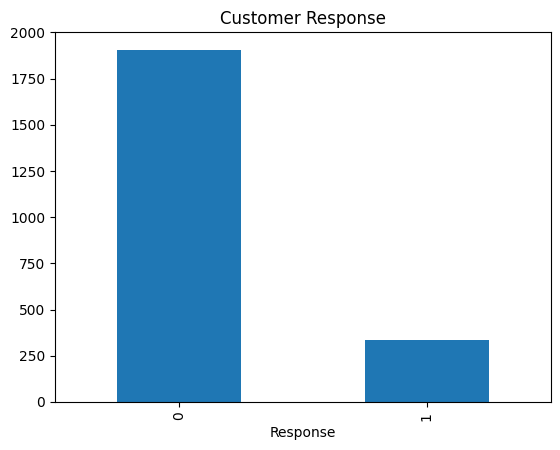

In [53]:
df['Response'].value_counts().plot(kind='bar')
plt.title("Customer Response")
plt.show()

In [54]:
from sklearn.cluster import KMeans
X_cluster = df[['Income','Total_Spending']]
kmeans = KMeans(n_clusters= 4)
df['Cluster'] = kmeans.fit_predict(X_cluster)

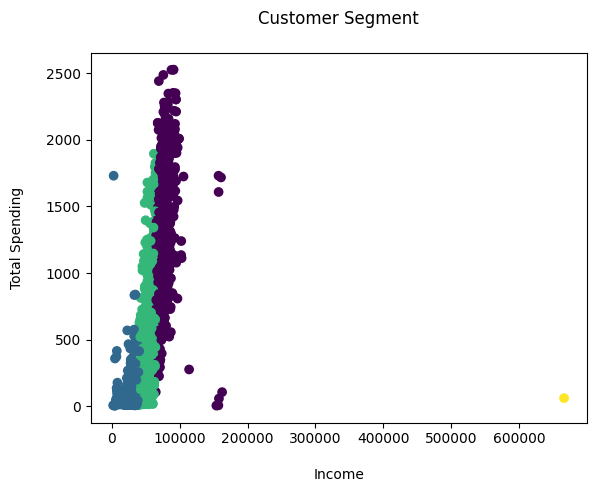

In [55]:
plt.scatter(df['Income'], df['Total_Spending'], c = df['Cluster'])
plt.xlabel("\nIncome")
plt.ylabel("Total Spending\n")
plt.title("Customer Segment\n")
plt.show()

In [56]:
df['Cluster'].unique()

array([2, 0, 1, 3], dtype=int32)

💥 Q1: Load & Inspect Data

👉 Task:

Load dataset
Show first 5 rows
Show info

In [57]:
df = pd.read_csv('Datasets\defaulter.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   defaulter  10000 non-null  str    
 1   student    10000 non-null  str    
 2   balance    10000 non-null  float64
 3   income     10000 non-null  float64
dtypes: float64(2), str(2)
memory usage: 312.6 KB


In [58]:
df.head()

,defaulter,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [59]:
df.isnull().sum()

defaulter    0
student      0
balance      0
income       0
dtype: int64

In [60]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['defaulter'] = encoder.fit_transform(df['defaulter'])
df['student'] = encoder.fit_transform(df['student'])

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   defaulter  10000 non-null  int64  
 1   student    10000 non-null  int64  
 2   balance    10000 non-null  float64
 3   income     10000 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 312.6 KB


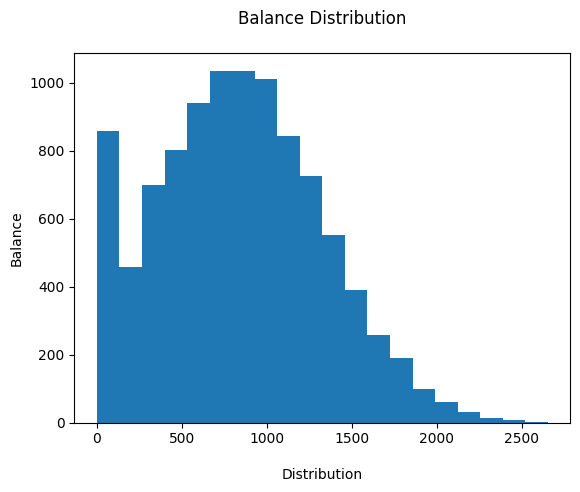

In [62]:
plt.hist(df['balance'], bins= 20)
plt.title("Balance Distribution\n")
plt.xlabel("\nDistribution")
plt.ylabel("Balance")
plt.show()

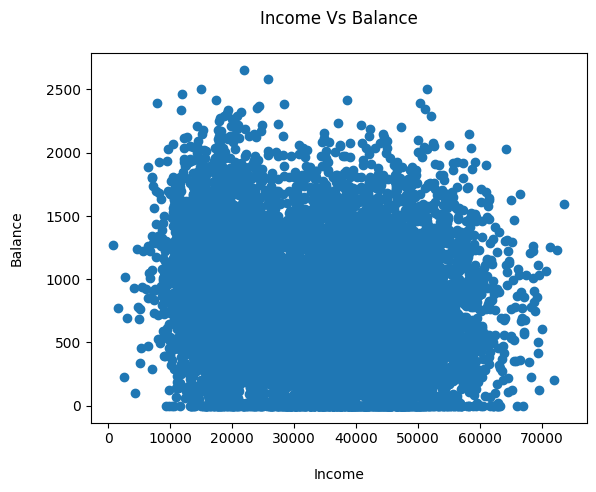

In [63]:
plt.scatter(df['income'], df['balance'])
plt.title("Income Vs Balance\n")
plt.xlabel("\nIncome")
plt.ylabel("Balance\n")
plt.show()

In [64]:
df.groupby('student')['defaulter'].sum()

student
0    206
1    127
Name: defaulter, dtype: int64

In [65]:
df.groupby('student')['defaulter'].value_counts()

student  defaulter
0        0            6850
         1             206
1        0            2817
         1             127
Name: count, dtype: int64

In [66]:
# EXERCISE 3: PCA ON MATRIX

import numpy as np
from sklearn.decomposition import PCA

# Example matrix
X = np.array([
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6]
])

# Apply PCA
pca = PCA(n_components=1)
X_reduced = pca.fit_transform(X)

print("Original Data:\n", X)
print("Reduced Data:\n", X_reduced)
print("Explained Variance:", pca.explained_variance_ratio_)

Original Data:
 [[2 3]
 [3 4]
 [4 5]
 [5 6]]
Reduced Data:
 [[-2.12132034]
 [-0.70710678]
 [ 0.70710678]
 [ 2.12132034]]
Explained Variance: [1.]


Shape: (1596, 12)
Columns: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')
<class 'pandas.DataFrame'>
Index: 1357 entries, 0 to 1595
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1357 non-null   float64
 1   volatile acidity      1357 non-null   float64
 2   citric acid           1357 non-null   float64
 3   residual sugar        1357 non-null   float64
 4   chlorides             1357 non-null   float64
 5   free sulfur dioxide   1357 non-null   float64
 6   total sulfur dioxide  1357 non-null   float64
 7   density               1357 non-null   float64
 8   pH                    1357 non-null   float64
 9   sulphates             1357 non-null   float64
 10  alcohol               1357 non-null   floa

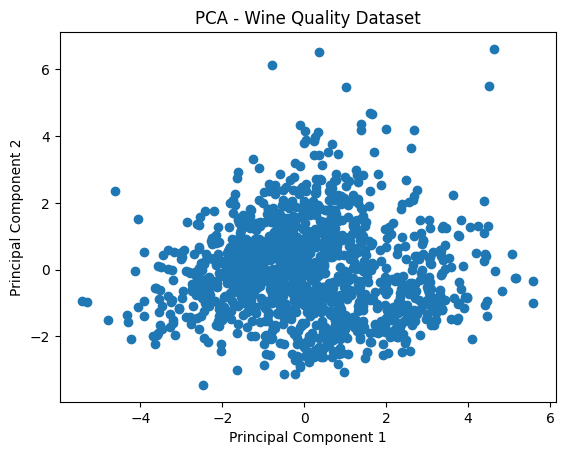

Explained Variance Ratio: [0.28104762 0.17405318]
Total Variance Covered: 0.4551008063956684


In [67]:
# EXERCISE 4: PCA ON winequality-red.csv

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------
# 1. Load dataset
# -------------------------------
df = pd.read_csv("Datasets\winequality-red.csv")

print("Shape:", df.shape)
print("Columns:", df.columns)
df = df.drop_duplicates()
print(df.info())

# -------------------------------
# 2. Separate features and target
# -------------------------------
X = df.drop('quality', axis=1)   # features
y = df['quality']                # target (optional)

# -------------------------------
# 3. Feature Scaling (VERY IMPORTANT)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 4. Apply PCA (reduce to 2 components)
# -------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------------------------------
# 5. Visualize PCA
# -------------------------------
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Wine Quality Dataset")
plt.show()

# -------------------------------
# 6. Explained Variance
# -------------------------------
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Covered:", sum(pca.explained_variance_ratio_))

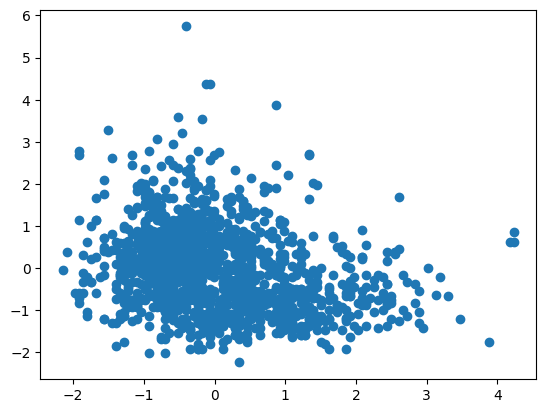

In [68]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from pyclustering.cluster.kmeans import kmeans

df = pd.read_csv('iris.csv')
X = df.drop("Species", axis= 1)
kmeans_model = KMeans(n_clusters= 3, random_state= 42)
labels_k3 = kmeans_model.fit_predict(X)

interia = []

for k in range(1,10):
    model = KMeans(n_clusters= k, random_state= 42)
    model.fit(X)
    interia.append(model.inertia_)

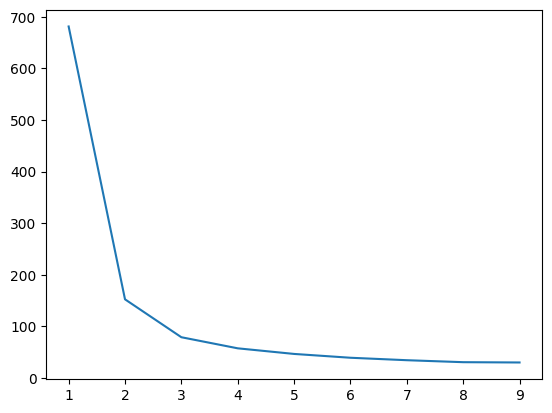

In [21]:
plt.plot(range(1,10), interia)
plt.show()

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   12            19000          0
1  15810944    Male   11            20000          0
2  15668575  Female    1            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   10            76000          0
<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          99 non-null     int64
 1   Gender           99 non-null     str  
 2   Age              99 non-null     int64
 3   EstimatedSalary  99 non-null     int64
 4   Purchased        99 non-null     int64
dtypes: int64(4), str(1)
memory usage: 4.0 KB
None
Encoded Columns: Index(['Age', 'EstimatedSalary', 'Gender_Male'], dtype='str')
Train Accuracy: 0.9873417721518988
Test Accuracy: 0.8


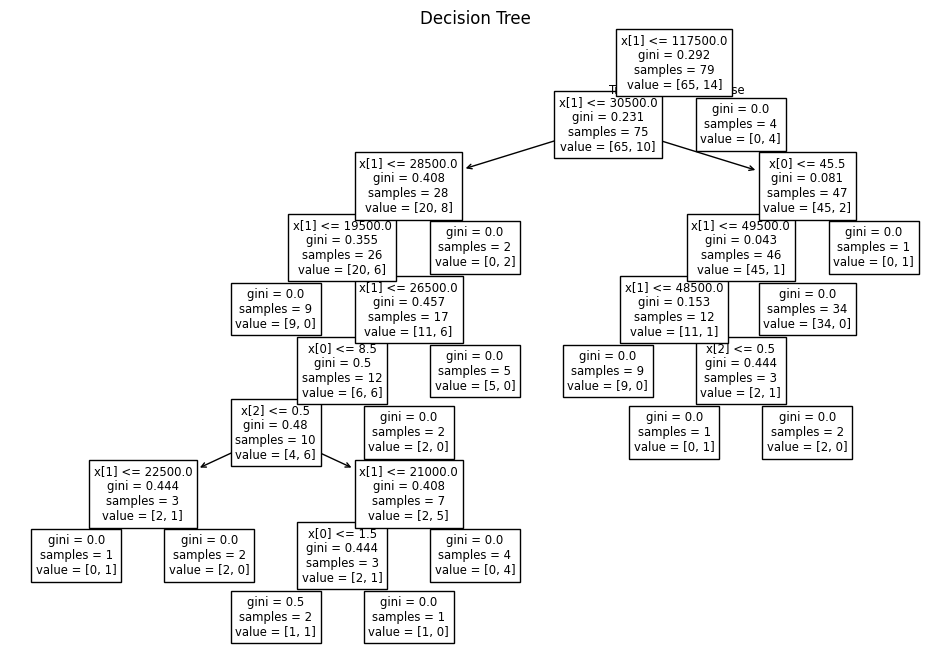

In [28]:
# DECISION TREE CLASSIFICATION (users.csv)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load dataset
# -------------------------------
df = pd.read_csv("users.csv")

print(df.head())
print(df.info())

# -------------------------------
# 2. Assign predictors (X) and target (y)
# -------------------------------
X = df.drop(['User ID', 'Purchased'], axis=1)
y = df['Purchased']

# -------------------------------
# 3. Encode categorical data
# -------------------------------
X = pd.get_dummies(X, drop_first=True)

print("Encoded Columns:", X.columns)

# -------------------------------
# 4. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 5. Build Decision Tree model
# -------------------------------
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 6. Predictions
# -------------------------------
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# -------------------------------
# 7. Evaluate performance
# -------------------------------
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# 8. Draw Decision Tree

plt.figure(figsize=(12,8))
plot_tree(model)
plt.title("Decision Tree")
plt.show()